## Loan Approval Prediction

In [1]:
#Fundamental ML Libraries

import pandas as pd #Data Processing
import numpy as np #Numerical Computation 
import matplotlib.pyplot as plt #Visualisation
import seaborn as sns #Visualisation

## Data Importation

In [2]:
loan_data = pd.read_csv('../data/loan.csv')

## Data Overview

In [3]:
loan_data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [4]:
loan_data.tail(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
604,LP002959,Female,Yes,1,Graduate,No,12000,0.0,496.0,360.0,1.0,Semiurban,Y
605,LP002960,Male,Yes,0,Not Graduate,No,2400,3800.0,NaN,180.0,1.0,Urban,N
606,LP002961,Male,Yes,1,Graduate,No,3400,2500.0,173.0,360.0,1.0,Semiurban,Y
607,LP002964,Male,Yes,2,Not Graduate,No,3987,1411.0,157.0,360.0,1.0,Rural,Y
608,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


## Observations

In [5]:
rows = loan_data.shape 
print(rows)
print(type(rows))

rows = loan_data.shape[0]
columns = loan_data.shape[1]

print(f'The number of rows in the data is {rows} and the number of columns is {columns}')

(614, 13)
<class 'tuple'>
The number of rows in the data is 614 and the number of columns is 13


In [6]:
loan_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [7]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
loan_data['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [9]:
loan_data['Loan_Status'] = loan_data['Loan_Status'].map({'N':0, 'Y':1})

In [10]:
loan_data['Loan_Status'].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

## Data Cleaning

In [11]:
loan_data.isnull().sum().sum()

np.int64(149)

In [12]:
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in categorical_cols:
    loan_data[col] = loan_data[col].fillna(loan_data[col].mode()[0])

In [13]:
loan_data['LoanAmount'] = loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].median())

In [14]:
loan_data.isnull().sum().sum()

np.int64(0)

In [15]:
loan_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1


In [16]:
loan_data.duplicated().sum().sum()

np.int64(0)

In [17]:
loan_data.drop('Loan_ID', axis=1, inplace=True)

In [18]:
loan_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1


In [19]:
loan_data["Loan_Status"].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [20]:
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049,0.687296
std,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.463973
min,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000


## EDA

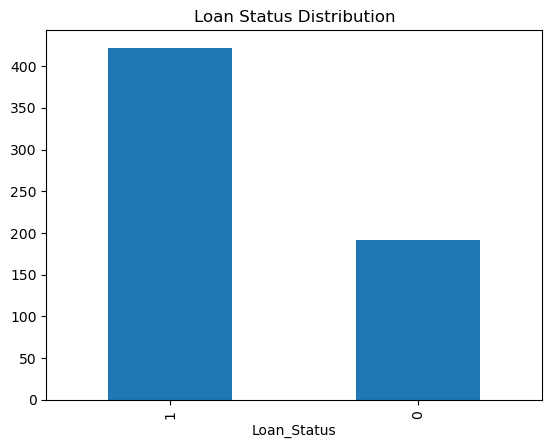

In [21]:
loan_data["Loan_Status"].value_counts().plot(kind="bar")
plt.title("Loan Status Distribution")
plt.show()

## Modeling

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

In [23]:
le = LabelEncoder()

In [24]:
loan_data["Gender"] = le.fit_transform(loan_data["Gender"])

In [25]:
loan_data["Married"] = le.fit_transform(loan_data["Married"])

In [26]:
loan_data["Dependents"] = loan_data["Dependents"].replace("3+", "3")

In [27]:
loan_data["Dependents"] = le.fit_transform(loan_data["Dependents"])

In [28]:
loan_data["Education"] = le.fit_transform(loan_data["Education"])

In [29]:
loan_data["Self_Employed"] = le.fit_transform(loan_data["Self_Employed"])

In [30]:
loan_data["Property_Area"] = le.fit_transform(loan_data["Property_Area"])

In [31]:
loan_data.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
5,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1
6,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1
7,1,1,3,0,0,3036,2504.0,158.0,360.0,0.0,1,0
8,1,1,2,0,0,4006,1526.0,168.0,360.0,1.0,2,1
9,1,1,1,0,0,12841,10968.0,349.0,360.0,1.0,1,0


In [32]:
from imblearn.over_sampling import SMOTE

x = loan_data.drop("Loan_Status", axis=1)
y = loan_data["Loan_Status"]

smote = SMOTE(random_state=42)

x_smote, y_smote = smote.fit_resample(x, y)

In [33]:
print(y_smote.value_counts())

Loan_Status
1    422
0    422
Name: count, dtype: int64


In [34]:
x = loan_data.drop("Loan_Status", axis=1)
y = loan_data["Loan_Status"]

In [35]:
numeric_cols = x.select_dtypes(include = ['number']).columns.tolist()
categorical_cols = x.select_dtypes(include = ['object']).columns.tolist()

In [36]:
numeric_cols

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area']

In [37]:
categorical_cols

[]

## Pipeline

In [38]:
numeric_pipeline = Pipeline(steps = [('numericPipeline', StandardScaler())]) 
categorical_pipeline = Pipeline(steps = [('categoricalPipeline', OneHotEncoder(handle_unknown = 'ignore'))])

In [39]:
from sklearn.compose import ColumnTransformer

In [40]:
#Preprocessing pipeline
ml_preprocess = ColumnTransformer(

    transformers = [

        ('TransformNumeric', numeric_pipeline, numeric_cols),
        ('TransformCategory', categorical_pipeline, categorical_cols),
        
    ])
        

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
x_train, x_test, y_train, y_test = train_test_split(
    x_smote,
    y_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_smote
)

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_balanced, y_train_balanced = smote.fit_resample(
    x_train,
    y_train
)

In [44]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [45]:
lr_model = Pipeline(steps=[
    ("preprocess", ml_preprocess),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [46]:
dt_model = Pipeline(steps=[
    ("preprocess", ml_preprocess),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [47]:
rf_model = Pipeline(steps=[
    ("preprocess", ml_preprocess),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [48]:
nb_model = Pipeline(steps=[
    ("preprocess", ml_preprocess),
    ("classifier", GaussianNB())
])

In [49]:
knn_model = Pipeline(steps=[
    ("preprocess", ml_preprocess),
    ("classifier", KNeighborsClassifier())
])

In [50]:
svm_model = Pipeline(steps=[
    ("preprocess", ml_preprocess),
    ("classifier", SVC(probability=True, random_state=42))
])

In [51]:
models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Naive Bayes': nb_model,
    'KNN': knn_model,
    'SVM': svm_model
}

## Training the models

In [52]:
for name, model in models.items():
    model.fit(x_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Naive Bayes trained successfully.
KNN trained successfully.
SVM trained successfully.


In [53]:
lr_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
dt_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
rf_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
nb_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
knn_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
svm_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Testing the models

In [59]:
lr_y = lr_model.predict(x_test)
dt_y = dt_model.predict(x_test)
rf_y = rf_model.predict(x_test)
nb_y = nb_model.predict(x_test)
knn_y = knn_model.predict(x_test)
svm_y = svm_model.predict(x_test)

## Performance Evaluation

In [60]:
y_test.value_counts()

Loan_Status
0    85
1    84
Name: count, dtype: int64

In [61]:
results = []

for name, model in models.items():

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.66      0.75        85
           1       0.72      0.90      0.80        84

    accuracy                           0.78       169
   macro avg       0.80      0.78      0.78       169
weighted avg       0.80      0.78      0.78       169

Decision Tree
              precision    recall  f1-score   support

           0       0.78      0.81      0.79        85
           1       0.80      0.76      0.78        84

    accuracy                           0.79       169
   macro avg       0.79      0.79      0.79       169
weighted avg       0.79      0.79      0.79       169

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.78      0.81        85
           1       0.79      0.87      0.83        84

    accuracy                           0.82       169
   macro avg       0.83      0.82      0.82       169
weighted avg       0.83   

In [62]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.822485,0.793478,0.869048,0.829545
1,Decision Tree,0.786982,0.800000,0.761905,0.780488
0,Logistic Regression,0.781065,0.723810,0.904762,0.804233
4,KNN,0.763314,0.724490,0.845238,0.780220
3,Naive Bayes,0.757396,0.686957,0.940476,0.793970
5,SVM,0.757396,0.683761,0.952381,0.796020


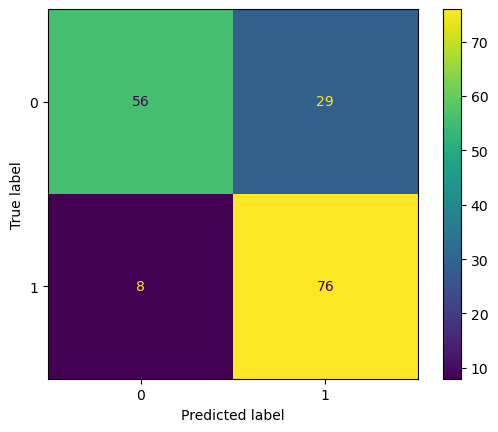

In [63]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_y)
plt.show()

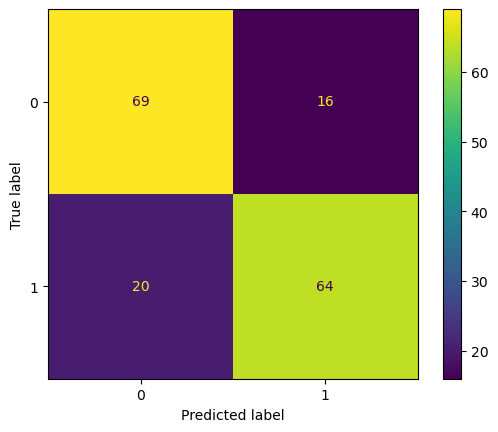

In [64]:
ConfusionMatrixDisplay.from_predictions(y_test, dt_y)
plt.show()

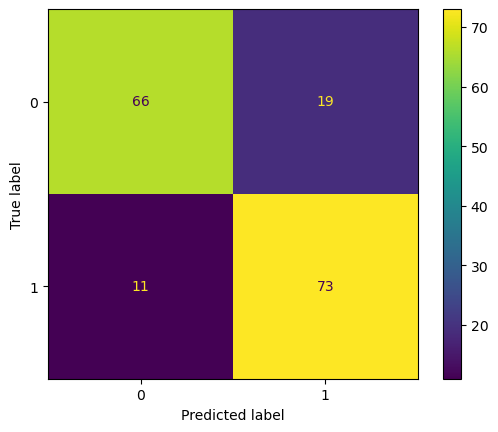

In [65]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_y)
plt.show()

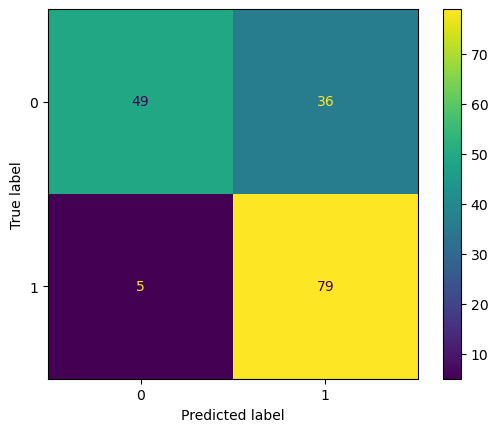

In [66]:
ConfusionMatrixDisplay.from_predictions(y_test, nb_y)
plt.show()

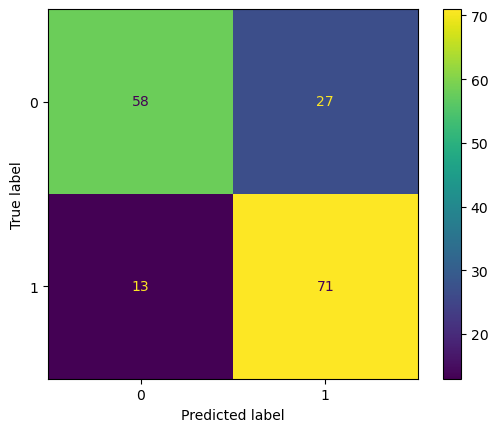

In [67]:
ConfusionMatrixDisplay.from_predictions(y_test, knn_y)
plt.show()

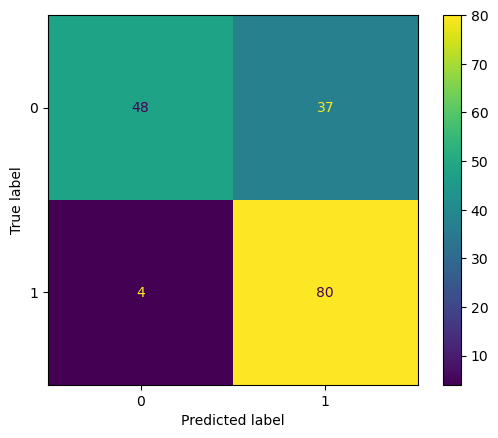

In [68]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_y)
plt.show()

In [69]:
best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print(best_model)

Model        Random Forest
Accuracy          0.822485
Precision         0.793478
Recall            0.869048
F1 Score          0.829545
Name: 2, dtype: object


In [71]:
import joblib

joblib.dump(rf_model, "../Model/loan_approval_pipeline.pkl")

['../Model/loan_approval_pipeline.pkl']

In [72]:
pipeline = joblib.load("../Model/loan_approval_pipeline.pkl")